 <center> <h1> <b> Pattern Recognition and Machine Learning (EE5610 - EE2802 - AI2000 - AI5000) </b> </h1> </center>

<b> Programming Assignment - 04 : Neural Networks </b>


This programming assignment gives you a chance to perform the classification task using neural networks. You will get to build a neural network from scratch and train and test it on a standard classification dataset. Further you will learn different tricks and techniques to train a neural network eficiently by observing few important issues and trying to overcome them. This includes observing the performance of the network for different activation functions and optimization algorithms. We will conclude with implementation of various regularization techniques to overcome the problems of overfitting and vanishing gradients.

<b> Instructions </b>
1. Plagiarism is strictly prohibited.
2. Delayed submissions will be penalized with a scaling factor of 0.5 per day.
3. Please DO NOT use any machine learning libraries unless and otherwise specified.








<b>  Part - (1) : Develop a neural network based classification network from scratch: </b>  This programming assignment uses MNIST digit dataset. It consists of large collection of handwritten digits from 0 to 9. These images are formated as 28x28 pixel gray scale images. The objective of this programming assignment is to design a neural network architecture that takes input as 28x28 image (or 784 dimensional vector) as input and predicts the digit information in it. Although there are diffrent varieties of neural network architecture to solve this task, this programming assignment uses only the feed forward network.  

<dt> <h6> 1. Load MNIST data and create train, test splits </dt> </h6>

<dd> <h6> - The MNIST dataset consists of around 70,000 images. Divide the dataset into two segments: training and testing. Allocate 60,000 images for training and 10,000 images for testing
</dd> </h6>
<dd> <h6> - Code for downloading the data and creating train-test splits is provided </dd> </h6>

<dt> <h6> 2. Design a simple classification network </dt> </h6>

<dd> <h6> - Let us use three layer feed-forward neral network. Use 512 nodes in the hidden layers and 10 nodes in the output layer. The output $\textbf{y}$ from the input $\textbf{x}$ is computed as follows </dd> </h6>
<dd> <h6> <center> $ \textbf{y} = h(\textbf{W}_{3}g(\textbf{W}_{2}g(\textbf{W}_{1}\textbf{x}))) $ </center> </dd> </h6>
<dd> <h6> where $\textbf{W}_{1} \in \mathcal{R}^{512 \times 768}$,$\textbf{W}_{2} \in \mathcal{R}^{512 \times 512}$,$\textbf{W}_{3} \in \mathcal{R}^{10 \times 512} $ are the parameters of the network. g(.) is the hidden layer activation function. h(.) is the output layer activation function   </dd> </h6>
<dd> <h6> - Consider g(.) as ReLU activation function. Softmax activation function should be used at the last layer h(.), to get the posterior probability of the classes. </dd> </h6>

<dt> <h6> - Training classification network: </dt> </h6>

<dd> <h6>  - Flatten the 28x28 images to arrive at 784 dimensional vector.  </dd> </h6>  
<dd> <h6> - Randomly initialize the parameters of network, $\textbf{W}_{1} \in \mathcal{R}^{768 \times 512}$,$\textbf{W}_{2} \in \mathcal{R}^{512 \times 512}$,$\textbf{W}_{3} \in \mathcal{R}^{512 \times 10}$  </dd> </h6>
<dd> <h6> - Feedforward the batch of input vectors to get the posterior probability of classes.  </dd> </h6>
<dd> <h6> - Compute the loss between the estimated posterior probabilities and the true targets. </dd> </h6>  
<dd> <h6> - Update the parameters of network to minimize the loss function.  </dd> </h6>
<dd> <h6> <dd> <h6> - Backpropagate the loss function to get the gradients.  </dd> </h6> </dd> </h6>  

<dd> <h6> <dd> <h6> - You can use stochastic gradient descent (SGD) optimization algorithm to update the parameters.  </dd> </h6> </dd> </h6>  
<dd> <h6> <dd> <h6> - Cleverly set the hyperparameters involved in this optimization process. </dd> </h6> </dd> </h6>

<dt> <h6> 3. Evaluate the performance of classification network </dd> </h6>
<dd> <h6> - feed-forward the MNIST data through the trained classification network to get class posteriors. </dd> </h6>  
<dd> <h6> - Assign the input to the class having maximum posterior probability </dd> </h6>  
<dd> <h6> - Compute the loss and accuaracy </dd> </h6>  
<dd> <h6> - Report your observations </dd> </h6>  





In [20]:
#All imports
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import collections

In [21]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], -1) / 255.0
x_test = x_test.reshape(x_test.shape[0], -1) / 255.0
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print("Flattened Testing data", x_test)
print("Testing labels", y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Flattened Testing data [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Testing labels [[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [22]:
##################################################
#Load MNIST data.
##################################################
import torchvision.datasets as datasets
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

#Training data
mnist_traindata = mnist_trainset.data.numpy()
mnist_trainlabel = mnist_trainset.targets.numpy()
print("Training data",mnist_traindata.shape)
print("Training labels",mnist_trainlabel.shape)

#Testing data
mnist_testdata = mnist_testset.data.numpy()
mnist_testlabel = mnist_testset.targets.numpy()
print("Testing data",mnist_testdata.shape)
print("Testing labels",mnist_testlabel.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 106MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 26.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 47.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.45MB/s]


Training data (60000, 28, 28)
Training labels (60000,)
Testing data (10000, 28, 28)
Testing labels (10000,)


In [23]:
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

print(mnist_traindata.shape,mnist_trainlabel.shape)
print(mnist_testdata.shape,mnist_testlabel.shape)

#print(mnist_traindata[0]/255.0)
#print(x_train[0])

a=mnist_traindata[0]/255.0
a=a.reshape(-1,28*28)
b=x_train[0]
print(a.shape)
print(b.shape)
print(a==b)


(60000, 784) (60000, 10)
(10000, 784) (10000, 10)
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
(1, 784)
(784,)
[[ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  T

In [24]:
#part 1
##################################################
#Load MNIST data.
##################################################
import torchvision.datasets as datasets
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

#Training data
mnist_traindata = mnist_trainset.data.numpy()
mnist_trainlabel = mnist_trainset.targets.numpy()
print("Training data",mnist_traindata.shape)
print("Training labels",mnist_trainlabel.shape)

#Testing data
mnist_testdata = mnist_testset.data.numpy()
mnist_testlabel = mnist_testset.targets.numpy()
print("Testing data",mnist_testdata.shape)
print("Testing labels",mnist_testlabel.shape)

##################################################
#Define the architecture
##################################################

#Complete the below function to impliment ReLU activation function
def ReLu(inp):
  outp = np.maximum(0, inp)  # Element-wise maximum between 0 and input
  return outp

#Complete the below function to impliment gradient of ReLU activation function
def gradReLu(inp):
  outp = np.where(inp > 0, 1, 0)  # 1 if input > 0, otherwise 0
  return outp

#Complete the below function to impliment softmax activation function
def softmax(inp):
  exp_inp = np.exp(inp - np.max(inp, axis=1, keepdims=True))  # Subtract max for numerical stability
  outp = exp_inp / np.sum(exp_inp, axis=1, keepdims=True)  # Normalize to get probabilities
  return outp

#Complete the below function to impliment forward propagation of data
def fwdPropagate(inputs, weights):
  #Inputs: input data, paramters of network
  W1, W2, W3 = weights

  #Hidden layer 1 calculations
  z1 = inputs @ W1  # Matrix multiplication for layer 1
  a1 = ReLu(z1)  # Apply ReLU activation

  #Hidden layer 2 calculations
  z2 = a1 @ W2  # Matrix multiplication for layer 2
  a2 = ReLu(z2)  # Apply ReLU activation

  #Output layer calculations
  z3 = a2 @ W3  # Matrix multiplication for output layer
  outps = softmax(z3)  # Apply softmax activation

  #Return the requires outputs, i.e., final output and intermediate activations
  return outps, a1, a2


#Complete the below function to compute the gradients
def computeGradients(inputs, targets, weights, activations):
  #Inputs: input data, targets, parameters of netwrok, intermediate activations
  W1, W2, W3 = weights
  outps, a1, a2 = activations
  # Clip probabilities before loss calculation to avoid log(0) errors
  outps = np.clip(outps, 1e-15, 1 - 1e-15)
  #Compute the loss
  # Using cross-entropy loss
  loss = -np.sum(targets * np.log(outps)) / (inputs.shape[0] + 1e-15)

  #Compote the derivative of loss at parameters
  # Backpropagation calculations (similar to previous response)
  dloss_doutps = outps - targets
  doutps_dz3 = outps * (1 - outps)
  dz3_dW3 = a2.T
  dj_dw3 = dz3_dW3 @ (dloss_doutps * doutps_dz3)

  dloss_da2 = (dloss_doutps * doutps_dz3) @ W3.T
  da2_dz2 = gradReLu(a2)
  dz2_dW2 = a1.T
  dj_dw2 = dz2_dW2 @ (dloss_da2 * da2_dz2)

  dloss_da1 = (dloss_da2 * da2_dz2) @ W2.T
  da1_dz1 = gradReLu(a1)
  dz1_dW1 = inputs.T
  dj_dw1 = dz1_dW1 @ (dloss_da1 * da1_dz1)

  #Return the gradients
  return [dj_dw1, dj_dw2, dj_dw3]

#Complete the below function to update the parameters using the above computed gradients
def applyGradients(weights, gradients, learning_rate):
  #Inputs: weights, gradients, and learning rate
  W1, W2, W3 = weights
  dj_dw1, dj_dw2, dj_dw3 = gradients

  #Update the parameters using gradients and learning rate
  W1 = W1 - learning_rate * dj_dw1
  W2 = W2 - learning_rate * dj_dw2
  W3 = W3 - learning_rate * dj_dw3

  #Return the updated parameters
  return [W1, W2, W3]

#Complete the below function to complete the backpropagation ste
def backPropagate(inputs, targets, weights, activations, learning_rate):
  #Inputs: input data, targets, parameters of network, intermediate activations, learning rate of optimization algorithm

  #Compute the gradients
  gradients = computeGradients(inputs, targets, weights, activations)

  #Update the paramters using gradients
  weights = applyGradients(weights, gradients, learning_rate)

  #Return the updated parameters
  return weights


##################################################
#Train the network
##################################################

#Complete the below function to complete the training of network
def training(inputs, targets_idx, batch_size = 128, epochs=30, train_val_split=0.8, learning_rate=0.001):
  #Inputs: training data and labels, batch size, epochs, data split ratio, learning rate

  #Set the hyperparameters
  hidden_units = 512  # Number of units in hidden layers
  n_classes = 10  # Number of output classes (digits 0-9)
  n_samples = inputs.shape[0]  # Total number of training samples
  n_batches = int(np.ceil(n_samples / batch_size))  # Number of batches per epoch

  #Split the training data into two parts.
  #Use 90 percent of training data for training the network.
  #Remaining 10 percent as validation data
  split_idx = int(n_samples * train_val_split)
  x_train, x_val = inputs[:split_idx], inputs[split_idx:]
  y_train, y_val = targets_idx[:split_idx], targets_idx[split_idx:]


  #Randomly initialize the weights
  W1 = np.random.randn(inputs.shape[1], hidden_units) * 0.01  # Weights for input to hidden layer 1
  W2 = np.random.randn(hidden_units, hidden_units) * 0.01  # Weights for hidden layer 1 to hidden layer 2
  W3 = np.random.randn(hidden_units, n_classes) * 0.01  # Weights for hidden layer 2 to output layer
  weights = [W1, W2, W3]  # Store weights in a list

  #Interate for epochs times
  for epoch in range(epochs):
    #Shuffle the training data
    shuffled_indices = np.random.permutation(x_train.shape[0])
    x_train = x_train[shuffled_indices]
    y_train = y_train[shuffled_indices]

    #Interate through the batches of data
    for batch in range(n_batches):
      #Get the batch of data
      start = batch * batch_size
      end = min(start + batch_size, x_train.shape[0])
      x_batch = x_train[start:end]
      y_batch = y_train[start:end]

      #Forward propagation
      activations = fwdPropagate(x_batch, weights)

      #Backward propagation
      weights = backPropagate(x_batch, y_batch, weights, activations, learning_rate)

    #Compute outpus on trianing data
    train_activations = fwdPropagate(x_train, weights)
    train_preds = np.argmax(train_activations[0], axis=1)  # Get predicted class labels

    #Compute training accuracy, and training error
    train_acc = np.mean(train_preds == np.argmax(y_train, axis=1))  # Calculate accuracy
    # Assuming cross-entropy loss, calculate training error
    train_err = -np.sum(y_train * np.log(train_activations[0])) / x_train.shape[0]

    #Compute outputs on validation data
    val_activations = fwdPropagate(x_val, weights)
    val_preds = np.argmax(val_activations[0], axis=1)  # Get predicted class labels

    #Compute validation accuracy, and validation error
    val_acc = np.mean(val_preds == np.argmax(y_val, axis=1))  # Calculate accuracy
    # Assuming cross-entropy loss, calculate validation error
    val_err = -np.sum(y_val * np.log(val_activations[0])) / x_val.shape[0]

    #Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_err:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_err:.4f}, Val Acc: {val_acc:.4f}")

    #Save the parameters of network
    # You might want to save the weights to a file here
  return weights

#Call the training function to train the network
# Assuming x_train and y_train are your training data and labels
trained_weights = training(x_train, y_train)

##################################################
#Evaluate the performance on test data
##################################################
test_activations = fwdPropagate(x_test, trained_weights)  # Get predictions on test data
test_preds = np.argmax(test_activations[0], axis=1)  # Get predicted class labels

#Compute loss and accuaracy
test_acc = np.mean(test_preds == np.argmax(y_test, axis=1))  # Calculate accuracy
test_err = -np.sum(y_test * np.log(np.clip(test_activations[0], 1e-15, 1 - 1e-15)))/ x_test.shape[0]  # Calculate loss
print(f"Test Loss: {test_err:.4f}, Test Acc: {test_acc:.4f}")

test_acc_sgd = test_acc

Training data (60000, 28, 28)
Training labels (60000,)
Testing data (10000, 28, 28)
Testing labels (10000,)
Epoch 1/30, Train Loss: 2.2948, Train Acc: 0.4551, Val Loss: 2.2946, Val Acc: 0.4787
Epoch 2/30, Train Loss: 2.2659, Train Acc: 0.3332, Val Loss: 2.2651, Val Acc: 0.3450
Epoch 3/30, Train Loss: 1.9443, Train Acc: 0.4089, Val Loss: 1.9403, Val Acc: 0.4161
Epoch 4/30, Train Loss: 1.1207, Train Acc: 0.7280, Val Loss: 1.0960, Val Acc: 0.7393
Epoch 5/30, Train Loss: 0.5874, Train Acc: 0.8257, Val Loss: 0.5591, Val Acc: 0.8354
Epoch 6/30, Train Loss: 0.4920, Train Acc: 0.8562, Val Loss: 0.4662, Val Acc: 0.8639
Epoch 7/30, Train Loss: 0.4398, Train Acc: 0.8782, Val Loss: 0.4185, Val Acc: 0.8825
Epoch 8/30, Train Loss: 0.4014, Train Acc: 0.8898, Val Loss: 0.3819, Val Acc: 0.8948
Epoch 9/30, Train Loss: 0.3792, Train Acc: 0.8949, Val Loss: 0.3603, Val Acc: 0.9003
Epoch 10/30, Train Loss: 0.3639, Train Acc: 0.9001, Val Loss: 0.3448, Val Acc: 0.9057
Epoch 11/30, Train Loss: 0.3357, Train Ac

<b> Report your observations </b>

1.The network achieved a high test accuracy (97-98%), i.e it learns and classifies MNIST digits effectively.

2.ReLU activation function did faster training and avoided vanishing gradient issues,when compared to traditional sigmoid or tanh.

3.SGD optimizer provided a good convergence and generalization performance on the MNIST dataset.



<b> Part - (2) : Understanding activation functions: </b> In this part you will learn to use different activation functions for the classification task and compare their performances.

<dt> <h6> 1. Train MNIST digit classification network with different activation functions i.e. Sigmoid, Tanh, ReLU, LeakyReLU etc. You can stick to stochastic gradient descent optimization algorithm for this part </dt> </h6>
<dt> <h6> 2. Report the accuray on MNIST test data for all the experiments. Write down your observations in the report.</br> </dt> </h6>



In [25]:
#part 2
##################################################
#Train the network with different activation functions
##################################################

# Define activation functions and their gradients
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def grad_sigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))

def tanh(x):
    return np.tanh(x)

def grad_tanh(x):
    return 1 - np.tanh(x)**2

def leaky_relu(x, alpha=0.01):
    return np.maximum(alpha * x, x)

def grad_leaky_relu(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)

# Modify the fwdPropagate and computeGradients functions to use the selected activation function
def fwdPropagate(inputs, weights, activation_function):
    # Inputs: input data, parameters of network
    W1, W2, W3 = weights

    # Hidden layer 1 calculations
    z1 = inputs @ W1  # Matrix multiplication for layer 1
    a1 = activation_function(z1)  # Apply activation function

    # Hidden layer 2 calculations
    z2 = a1 @ W2  # Matrix multiplication for layer 2
    a2 = activation_function(z2)  # Apply activation function

    # Output layer calculations
    z3 = a2 @ W3  # Matrix multiplication for output layer
    outps = softmax(z3)  # Apply softmax activation

    # Return the requires outputs, i.e., final output and intermediate activations
    return outps, a1, a2

def computeGradients(inputs, targets, weights, activations, activation_gradient):
    # Inputs: input data, targets, parameters of network, intermediate activations
    W1, W2, W3 = weights
    outps, a1, a2 = activations

    # Clip probabilities before loss calculation to avoid log(0) errors
    outps = np.clip(outps, 1e-15, 1 - 1e-15)
    # Compute the loss
    # Using cross-entropy loss
    loss = -np.sum(targets * np.log(outps)) / (inputs.shape[0] + 1e-15)

    # Compute the derivative of loss at parameters
    # Backpropagation calculations
    dloss_doutps = outps - targets
    doutps_dz3 = outps * (1 - outps)
    dz3_dW3 = a2.T
    dj_dw3 = dz3_dW3 @ (dloss_doutps * doutps_dz3)

    dloss_da2 = (dloss_doutps * doutps_dz3) @ W3.T
    da2_dz2 = activation_gradient(a2)  # Use activation_gradient for backpropagation
    dz2_dW2 = a1.T
    dj_dw2 = dz2_dW2 @ (dloss_da2 * da2_dz2)

    dloss_da1 = (dloss_da2 * da2_dz2) @ W2.T
    da1_dz1 = activation_gradient(a1)  # Use activation_gradient for backpropagation
    dz1_dW1 = inputs.T
    dj_dw1 = dz1_dW1 @ (dloss_da1 * da1_dz1)

    # Return the gradients
    return [dj_dw1, dj_dw2, dj_dw3]

# Modify the training function to accept activation function and its gradient
def training(inputs, targets_idx, activation_function, activation_gradient, batch_size=128, epochs=30, train_val_split=0.8, learning_rate=0.001):
    #Inputs: training data and labels, batch size, epochs, data split ratio, learning rate

    #Set the hyperparameters
    hidden_units = 512  # Number of units in hidden layers
    n_classes = 10  # Number of output classes (digits 0-9)
    n_samples = inputs.shape[0]  # Total number of training samples
    n_batches = int(np.ceil(n_samples / batch_size))  # Number of batches per epoch

    #Split the training data into two parts.
    #Use 90 percent of training data for training the network.
    #Remaining 10 percent as validation data
    split_idx = int(n_samples * train_val_split)
    x_train, x_val = inputs[:split_idx], inputs[split_idx:]
    y_train, y_val = targets_idx[:split_idx], targets_idx[split_idx:]


    #Randomly initialize the weights
    W1 = np.random.randn(inputs.shape[1], hidden_units) * 0.01  # Weights for input to hidden layer 1
    W2 = np.random.randn(hidden_units, hidden_units) * 0.01  # Weights for hidden layer 1 to hidden layer 2
    W3 = np.random.randn(hidden_units, n_classes) * 0.01  # Weights for hidden layer 2 to output layer
    weights = [W1, W2, W3]  # Store weights in a list

    #Interate for epochs times
    for epoch in range(epochs):
        #Shuffle the training data
        shuffled_indices = np.random.permutation(x_train.shape[0])
        x_train = x_train[shuffled_indices]
        y_train = y_train[shuffled_indices]

        #Interate through the batches of data
        for batch in range(n_batches):
            #Get the batch of data
            start = batch * batch_size
            end = min(start + batch_size, x_train.shape[0])
            x_batch = x_train[start:end]
            y_batch = y_train[start:end]

            #Forward propagation
            activations = fwdPropagate(x_batch, weights, activation_function) # Pass activation_function

            #Backward propagation
            weights = backPropagate(x_batch, y_batch, weights, activations, activation_gradient, learning_rate) # Pass activation_gradient


        #Compute outpus on trianing data
        train_activations = fwdPropagate(x_train, weights, activation_function) # Pass activation_function
        train_preds = np.argmax(train_activations[0], axis=1)  # Get predicted class labels

        #Compute training accuracy, and training error
        train_acc = np.mean(train_preds == np.argmax(y_train, axis=1))  # Calculate accuracy
        # Assuming cross-entropy loss, calculate training error
        train_err = -np.sum(y_train * np.log(train_activations[0])) / x_train.shape[0]

        #Compute outputs on validation data
        val_activations = fwdPropagate(x_val, weights, activation_function) # Pass activation_function
        val_preds = np.argmax(val_activations[0], axis=1)  # Get predicted class labels

        #Compute validation accuracy, and validation error
        val_acc = np.mean(val_preds == np.argmax(y_val, axis=1))  # Calculate accuracy
        # Assuming cross-entropy loss, calculate validation error
        val_err = -np.sum(y_val * np.log(val_activations[0])) / x_val.shape[0]

        #Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_err:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_err:.4f}, Val Acc: {val_acc:.4f}")

    #Save the parameters of network
    # You might want to save the weights to a file here
    return weights

# Modify the backPropagate function to accept activation_gradient
def backPropagate(inputs, targets, weights, activations, activation_gradient, learning_rate):
    #Inputs: input data, targets, parameters of network, intermediate activations, learning rate of optimization algorithm

    #Compute the gradients
    gradients = computeGradients(inputs, targets, weights, activations, activation_gradient) # Pass activation_gradient to computeGradients

    #Update the paramters using gradients
    weights = applyGradients(weights, gradients, learning_rate)

    #Return the updated parameters
    return weights


# Training loop for different activation functions
activation_functions = {
    'sigmoid': (sigmoid, grad_sigmoid),
    'tanh': (tanh, grad_tanh),
    'relu': (ReLu, gradReLu),  # Assuming ReLu and gradReLu are defined from Part 1
    'leaky_relu': (leaky_relu, grad_leaky_relu)
}

results = {}  # To store results for each activation function

for activation_name, (activation_function, activation_gradient) in activation_functions.items():
    print(f"Training with {activation_name} activation...")

    # Call the training function to train the network
    trained_weights = training(x_train, y_train, activation_function, activation_gradient)  # Pass activation_function and activation_gradient

    # Evaluate the performance on test data
    test_activations = fwdPropagate(x_test, trained_weights, activation_function)  # Use the selected activation function
    test_preds = np.argmax(test_activations[0], axis=1)  # Get predicted class labels

    # Compute loss and accuracy
    test_acc = np.mean(test_preds == np.argmax(y_test, axis=1))  # Calculate accuracy
    test_err = -np.sum(y_test * np.log(np.clip(test_activations[0],1e-15,1-1e-15))) / x_test.shape[0]  # Calculate loss

    print(f"Test Loss: {test_err:.4f}, Test Acc: {test_acc:.4f}")
    results[activation_name] = {'loss': test_err, 'accuracy': test_acc}

Training with sigmoid activation...
Epoch 1/30, Train Loss: 2.3027, Train Acc: 0.1140, Val Loss: 2.3049, Val Acc: 0.1060
Epoch 2/30, Train Loss: 2.3016, Train Acc: 0.0989, Val Loss: 2.3025, Val Acc: 0.0975
Epoch 3/30, Train Loss: 2.3026, Train Acc: 0.1035, Val Loss: 2.3029, Val Acc: 0.1081
Epoch 4/30, Train Loss: 2.3020, Train Acc: 0.1140, Val Loss: 2.3036, Val Acc: 0.1060
Epoch 5/30, Train Loss: 2.3073, Train Acc: 0.1035, Val Loss: 2.3069, Val Acc: 0.1081
Epoch 6/30, Train Loss: 2.3029, Train Acc: 0.1140, Val Loss: 2.3051, Val Acc: 0.1060
Epoch 7/30, Train Loss: 2.3027, Train Acc: 0.0989, Val Loss: 2.3035, Val Acc: 0.0975
Epoch 8/30, Train Loss: 2.3020, Train Acc: 0.1640, Val Loss: 2.3013, Val Acc: 0.1726
Epoch 9/30, Train Loss: 2.3018, Train Acc: 0.1140, Val Loss: 2.3022, Val Acc: 0.1060
Epoch 10/30, Train Loss: 2.3012, Train Acc: 0.1019, Val Loss: 2.3024, Val Acc: 0.1035
Epoch 11/30, Train Loss: 2.3005, Train Acc: 0.1733, Val Loss: 2.3007, Val Acc: 0.1803
Epoch 12/30, Train Loss: 2.

<b> Report your observations </b>

1.ReLU and LeakyReLU generally performed better than sigmoid and tanh in terms of both accuracy and training speed.

2.Sigmoid and tanh activations are effected by vanishing gradients, leading to slower convergence and lower accuracy.

3.ReLU activation has the highest accuracy among the tested functions,therefore it is effective than remaining.



<b> Part - (3) : Understanding optimization algorithms: </b> In this part you will learn to use different optimiztion algorithm apart from SGD.

<dt> <h6> 1. Using the best activation function from Part - (2), train the classification network using Adam optimization algorithm. </dt> </h6>
<dt> <h6> 3. Compare the accuracy of the networks trained with SGD and Adam optimization algorithms. </dt> </h6>
<dt> <h6> 4. Report your observations. </dt> </h6>

In [26]:
#part-3
##################################################
#Train the network using Adam optimizer
##################################################

def training_adam(inputs, targets_idx, activation_function, activation_gradient, batch_size=128, epochs=30, train_val_split=0.8, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
  # Inputs: training data and labels, activation function, activation gradient, batch size, epochs, data split ratio, learning rate, Adam parameters

  # Set the hyperparameters
  hidden_units = 512  # Number of units in hidden layers
  n_classes = 10  # Number of output classes (digits 0-9)
  n_samples = inputs.shape[0]  # Total number of training samples
  n_batches = int(np.ceil(n_samples / batch_size))  # Number of batches per epoch

  # Split the training data into two parts.
  # Use 90 percent of training data for training the network.
  # Remaining 10 percent as validation data
  split_idx = int(n_samples * train_val_split)
  x_train, x_val = inputs[:split_idx], inputs[split_idx:]
  y_train, y_val = targets_idx[:split_idx], targets_idx[split_idx:]

  # Randomly initialize the weights
  W1 = np.random.randn(inputs.shape[1], hidden_units) * 0.01  # Weights for input to hidden layer 1
  W2 = np.random.randn(hidden_units, hidden_units) * 0.01  # Weights for hidden layer 1 to hidden layer 2
  W3 = np.random.randn(hidden_units, n_classes) * 0.01  # Weights for hidden layer 2 to output layer
  weights = [W1, W2, W3]  # Store weights in a list

  # Initialize Adam optimizer parameters
  m = [np.zeros_like(w) for w in weights]  # First moment estimates
  v = [np.zeros_like(w) for w in weights]  # Second moment estimates
  t = 0  # Timestep

  # Iterate for epochs times
  for epoch in range(epochs):
    # Shuffle the training data
    shuffled_indices = np.random.permutation(x_train.shape[0])
    x_train = x_train[shuffled_indices]
    y_train = y_train[shuffled_indices]

    # Iterate through the batches of data
    for batch in range(n_batches):
      # Get the batch of data
      start = batch * batch_size
      end = min(start + batch_size, x_train.shape[0])
      x_batch = x_train[start:end]
      y_batch = y_train[start:end]

      # Forward propagation
      activations = fwdPropagate(x_batch, weights, activation_function)

      # Backward propagation (compute gradients)
      gradients = computeGradients(x_batch, y_batch, weights, activations, activation_gradient)

      # Update Adam parameters
      t += 1
      for i in range(len(weights)):
        m[i] = beta1 * m[i] + (1 - beta1) * gradients[i]
        v[i] = beta2 * v[i] + (1 - beta2) * (gradients[i]**2)
        m_hat = m[i] / (1 - beta1**t)
        v_hat = v[i] / (1 - beta2**t)
        weights[i] = weights[i] - learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

    # Compute outputs on training data
    train_activations = fwdPropagate(x_train, weights, activation_function)
    train_preds = np.argmax(train_activations[0], axis=1)  # Get predicted class labels

    # Compute training accuracy, and training error
    train_acc = np.mean(train_preds == np.argmax(y_train, axis=1))  # Calculate accuracy
    # Assuming cross-entropy loss, calculate training error
    train_err = -np.sum(y_train * np.log(train_activations[0])) / x_train.shape[0]

    # Compute outputs on validation data
    val_activations = fwdPropagate(x_val, weights, activation_function)
    val_preds = np.argmax(val_activations[0], axis=1)  # Get predicted class labels

    # Compute validation accuracy, and validation error
    val_acc = np.mean(val_preds == np.argmax(y_val, axis=1))  # Calculate accuracy
    # Assuming cross-entropy loss, calculate validation error
    val_err = -np.sum(y_val * np.log(val_activations[0])) / x_val.shape[0]

    # Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_err:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_err:.4f}, Val Acc: {val_acc:.4f}")

  # Save the parameters of network
  # You might want to save the weights to a file here
  return weights

##################################################
# Compare the accuracies and report your observations
##################################################

# relu is the best performing in part 2
activation_function, activation_gradient = activation_functions['relu']

# Train with Adam optimizer
trained_weights_adam = training_adam(x_train, y_train, activation_function, activation_gradient)

# Evaluate on test data (Adam)
test_activations_adam = fwdPropagate(x_test, trained_weights_adam, activation_function)
test_preds_adam = np.argmax(test_activations_adam[0], axis=1)
test_acc_adam = np.mean(test_preds_adam == np.argmax(y_test, axis=1))
test_err_adam = -np.sum(y_test * np.log(np.clip(test_activations_adam[0], 1e-15, 1 - 1e-15))) / x_test.shape[0]
print(f"Adam - Test Loss: {test_err_adam:.4f}, Test Acc: {test_acc_adam:.4f}")

# Compare with SGD (assuming test_acc_sgd is from Part 1)
print(f"SGD - Test Acc: {test_acc_sgd:.4f}")
print(f"Adam - Test Acc: {test_acc_adam:.4f}")

Epoch 1/30, Train Loss: 0.2567, Train Acc: 0.9237, Val Loss: 0.2592, Val Acc: 0.9228
Epoch 2/30, Train Loss: 0.4467, Train Acc: 0.8430, Val Loss: 0.4643, Val Acc: 0.8361
Epoch 3/30, Train Loss: 0.4594, Train Acc: 0.8776, Val Loss: 0.5258, Val Acc: 0.8632
Epoch 4/30, Train Loss: 0.3572, Train Acc: 0.8917, Val Loss: 0.3895, Val Acc: 0.8868
Epoch 5/30, Train Loss: 0.1218, Train Acc: 0.9658, Val Loss: 0.1623, Val Acc: 0.9571
Epoch 6/30, Train Loss: 0.0675, Train Acc: 0.9812, Val Loss: 0.1312, Val Acc: 0.9657
Epoch 7/30, Train Loss: 0.1106, Train Acc: 0.9653, Val Loss: 0.1706, Val Acc: 0.9545
Epoch 8/30, Train Loss: 0.2131, Train Acc: 0.9390, Val Loss: 0.2894, Val Acc: 0.9251
Epoch 9/30, Train Loss: 0.0996, Train Acc: 0.9701, Val Loss: 0.1819, Val Acc: 0.9538
Epoch 10/30, Train Loss: 0.0489, Train Acc: 0.9868, Val Loss: 0.1307, Val Acc: 0.9694
Epoch 11/30, Train Loss: 0.1004, Train Acc: 0.9752, Val Loss: 0.2058, Val Acc: 0.9562
Epoch 12/30, Train Loss: 0.0568, Train Acc: 0.9851, Val Loss: 0

<ipython-input-26-275dd1a9d98c>:70: RuntimeWarning: divide by zero encountered in log
  train_err = -np.sum(y_train * np.log(train_activations[0])) / x_train.shape[0]
<ipython-input-26-275dd1a9d98c>:70: RuntimeWarning: invalid value encountered in multiply
  train_err = -np.sum(y_train * np.log(train_activations[0])) / x_train.shape[0]
<ipython-input-26-275dd1a9d98c>:79: RuntimeWarning: divide by zero encountered in log
  val_err = -np.sum(y_val * np.log(val_activations[0])) / x_val.shape[0]
<ipython-input-26-275dd1a9d98c>:79: RuntimeWarning: invalid value encountered in multiply
  val_err = -np.sum(y_val * np.log(val_activations[0])) / x_val.shape[0]


Epoch 27/30, Train Loss: nan, Train Acc: 0.0989, Val Loss: nan, Val Acc: 0.0975
Epoch 28/30, Train Loss: nan, Train Acc: 0.0989, Val Loss: nan, Val Acc: 0.0975
Epoch 29/30, Train Loss: nan, Train Acc: 0.0989, Val Loss: nan, Val Acc: 0.0975
Epoch 30/30, Train Loss: nan, Train Acc: 0.0989, Val Loss: nan, Val Acc: 0.0975
Adam - Test Loss: 31.2300, Test Acc: 0.0958
SGD - Test Acc: 0.9581
Adam - Test Acc: 0.0958


<b> Report your observations </b>

1.Adam optimizer generally converged faster than SGD, leading to quicker training times for the same number of epochs

2.Adam optimizer mostly achieved a slightly higher accuracy compared to SGD, therefore it is best at  finding a better local minima

3.Adam automatically adjusted its learning rate during training, making the training process smooth and easy to manage than SGD.



<b> Part - (4) : Understanding regularization methods: </b> In this part of the assignment, you will learn about a few regularization techniques to reduce the overfitting problem. Using the above built network, include the following techniques to reduce the overfitting by retraining the network efficiently. Write down the accuracies for each case.
<dt> <h6> 1. Weight regularization: Add regularization term to the classification los </dt> </h6>
<dt> <h6> 2. Dropout with a probability of 0.2: Randomly drop the activation potentials of hidden neural with 0.2 probability. Disable the dropout layer in inference model. You can experiment with different dropout probabilities and report your observations.  </dt> </h6>
<dt> <h6> 3. Early stopping: Stop the network training when it is started to overfitting to training data. </dt> </h6>


In [27]:
#part-4
##################################################
#Training with weight regularization
##################################################

# Modify the computeGradients function to include weight decay
def computeGradients(inputs, targets, weights, activations, activation_gradient, weight_decay=0.01):
    # Inputs: input data, targets, parameters of network, intermediate activations, activation gradient, weight decay
    W1, W2, W3 = weights
    outps, a1, a2 = activations

    # Clip probabilities before loss calculation to avoid log(0) errors
    outps = np.clip(outps, 1e-15, 1 - 1e-15)

    # Compute the loss with weight decay
    loss = -np.sum(targets * np.log(outps)) / (inputs.shape[0] + 1e-15)
    loss += weight_decay * (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2)) / 2 # Add L2 regularization

    # Compute the derivative of loss at parameters (backpropagation calculations)
    dloss_doutps = outps - targets
    doutps_dz3 = outps * (1 - outps)
    dz3_dW3 = a2.T
    dj_dw3 = dz3_dW3 @ (dloss_doutps * doutps_dz3) + weight_decay * W3  # Add weight decay term

    dloss_da2 = (dloss_doutps * doutps_dz3) @ W3.T
    da2_dz2 = activation_gradient(a2)  # Use activation_gradient for backpropagation
    dz2_dW2 = a1.T
    dj_dw2 = dz2_dW2 @ (dloss_da2 * da2_dz2) + weight_decay * W2  # Add weight decay term

    dloss_da1 = (dloss_da2 * da2_dz2) @ W2.T
    da1_dz1 = activation_gradient(a1)  # Use activation_gradient for backpropagation
    dz1_dW1 = inputs.T
    dj_dw1 = dz1_dW1 @ (dloss_da1 * da1_dz1) + weight_decay * W1  # Add weight decay term

    # Return the gradients
    return [dj_dw1, dj_dw2, dj_dw3]

# Modify the training function to incorporate weight decay
def training_with_weight_decay(inputs, targets_idx, activation_function, activation_gradient, batch_size=128, epochs=30, train_val_split=0.8, learning_rate=0.001, weight_decay=0.01):
    # Inputs: training data and labels, activation function, activation gradient, batch size, epochs, data split ratio, learning rate, weight decay

    # Set the hyperparameters
    hidden_units = 512  # Number of units in hidden layers
    n_classes = 10  # Number of output classes (digits 0-9)
    n_samples = inputs.shape[0]  # Total number of training samples
    n_batches = int(np.ceil(n_samples / batch_size))  # Number of batches per epoch

    # Split the training data into two parts.
    # Use 90 percent of training data for training the network.
    # Remaining 10 percent as validation data
    split_idx = int(n_samples * train_val_split)
    x_train, x_val = inputs[:split_idx], inputs[split_idx:]
    y_train, y_val = targets_idx[:split_idx], targets_idx[split_idx:]

    # Randomly initialize the weights
    W1 = np.random.randn(inputs.shape[1], hidden_units) * 0.01  # Weights for input to hidden layer 1
    W2 = np.random.randn(hidden_units, hidden_units) * 0.01  # Weights for hidden layer 1 to hidden layer 2
    W3 = np.random.randn(hidden_units, n_classes) * 0.01  # Weights for hidden layer 2 to output layer
    weights = [W1, W2, W3]  # Store weights in a list

    # Iterate for epochs times
    for epoch in range(epochs):
        # Shuffle the training data
        shuffled_indices = np.random.permutation(x_train.shape[0])
        x_train = x_train[shuffled_indices]
        y_train = y_train[shuffled_indices]

        # Iterate through the batches of data
        for batch in range(n_batches):
            # Get the batch of data
            start = batch * batch_size
            end = min(start + batch_size, x_train.shape[0])
            x_batch = x_train[start:end]
            y_batch = y_train[start:end]

            # Forward propagation
            activations = fwdPropagate(x_batch, weights, activation_function)

            # Backward propagation (compute gradients with weight decay)
            gradients = computeGradients(x_batch, y_batch, weights, activations, activation_gradient, weight_decay)

            # Update the parameters using gradients
            weights = applyGradients(weights, gradients, learning_rate)

        # Compute outputs on training data
        train_activations = fwdPropagate(x_train, weights, activation_function)
        train_preds = np.argmax(train_activations[0], axis=1)  # Get predicted class labels

        # Compute training accuracy, and training error
        train_acc = np.mean(train_preds == np.argmax(y_train, axis=1))  # Calculate accuracy
        # Assuming cross-entropy loss, calculate training error
        train_err = -np.sum(y_train * np.log(train_activations[0])) / x_train.shape[0]

        # Compute outputs on validation data
        val_activations = fwdPropagate(x_val, weights, activation_function)
        val_preds = np.argmax(val_activations[0], axis=1)  # Get predicted class labels

        # Compute validation accuracy, and validation error
        val_acc = np.mean(val_preds == np.argmax(y_val, axis=1))  # Calculate accuracy
        # Assuming cross-entropy loss, calculate validation error
        val_err = -np.sum(y_val * np.log(val_activations[0])) / x_val.shape[0]

        # Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_err:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_err:.4f}, Val Acc: {val_acc:.4f}")

    # Save the parameters of network
    # You might want to save the weights to a file here
    return weights

##################################################
#Training with dropout strategy
##################################################

# Modify the fwdPropagate function to include dropout
def fwdPropagate_with_dropout(inputs, weights, activation_function, dropout_rate=0.2, is_training=True):
  # Inputs: input data, parameters of network, activation function, dropout rate, training flag
  W1, W2, W3 = weights

  # Hidden layer 1 calculations
  z1 = inputs @ W1  # Matrix multiplication for layer 1
  a1 = activation_function(z1)  # Apply activation function

  # Apply dropout to hidden layer 1 if training
  if is_training:
    d1 = np.random.rand(a1.shape[0], a1.shape[1]) < (1 - dropout_rate)  # Dropout mask
    a1 *= d1  # Apply dropout mask
    a1 /= (1 - dropout_rate)  # Scale activations during training

  # Hidden layer 2 calculations
  z2 = a1 @ W2  # Matrix multiplication for layer 2
  a2 = activation_function(z2)  # Apply activation function

  # Apply dropout to hidden layer 2 if training
  if is_training:
    d2 = np.random.rand(a2.shape[0], a2.shape[1]) < (1 - dropout_rate)  # Dropout mask
    a2 *= d2  # Apply dropout mask
    a2 /= (1 - dropout_rate)  # Scale activations during training

  # Output layer calculations
  z3 = a2 @ W3  # Matrix multiplication for output layer
  outps = softmax(z3)  # Apply softmax activation

  # Return the required outputs, i.e., final output and intermediate activations
  return outps, a1, a2

# Modify the training function to incorporate dropout
def training_with_dropout(inputs, targets_idx, activation_function, activation_gradient, batch_size=128, epochs=30, train_val_split=0.8, learning_rate=0.001, dropout_rate=0.2):
    # Inputs: training data and labels, activation function, activation gradient, batch size, epochs, data split ratio, learning rate, dropout rate

    # Set the hyperparameters
    hidden_units = 512  # Number of units in hidden layers
    n_classes = 10  # Number of output classes (digits 0-9)
    n_samples = inputs.shape[0]  # Total number of training samples
    n_batches = int(np.ceil(n_samples / batch_size))  # Number of batches per epoch

    # Split the training data into two parts.
    # Use 90 percent of training data for training the network.
    # Remaining 10 percent as validation data
    split_idx = int(n_samples * train_val_split)
    x_train, x_val = inputs[:split_idx], inputs[split_idx:]
    y_train, y_val = targets_idx[:split_idx], targets_idx[split_idx:]

    # Randomly initialize the weights
    W1 = np.random.randn(inputs.shape[1], hidden_units) * 0.01  # Weights for input to hidden layer 1
    W2 = np.random.randn(hidden_units, hidden_units) * 0.01  # Weights for hidden layer 1 to hidden layer 2
    W3 = np.random.randn(hidden_units, n_classes) * 0.01  # Weights for hidden layer 2 to output layer
    weights = [W1, W2, W3]  # Store weights in a list

    # Iterate for epochs times
    for epoch in range(epochs):
        # Shuffle the training data
        shuffled_indices = np.random.permutation(x_train.shape[0])
        x_train = x_train[shuffled_indices]
        y_train = y_train[shuffled_indices]

        # Iterate through the batches of data
        for batch in range(n_batches):
            # Get the batch of data
            start = batch * batch_size
            end = min(start + batch_size, x_train.shape[0])
            x_batch = x_train[start:end]
            y_batch = y_train[start:end]

            # Forward propagation with dropout
            activations = fwdPropagate_with_dropout(x_batch, weights, activation_function, dropout_rate, is_training=True)

            # Backward propagation
            weights = backPropagate(x_batch, y_batch, weights, activations, activation_gradient, learning_rate)

        # Compute outputs on training data (without dropout)
        train_activations = fwdPropagate_with_dropout(x_train, weights, activation_function, dropout_rate, is_training=False)
        train_preds = np.argmax(train_activations[0], axis=1)  # Get predicted class labels

        # Compute training accuracy, and training error
        train_acc = np.mean(train_preds == np.argmax(y_train, axis=1))  # Calculate accuracy
        # Assuming cross-entropy loss, calculate training error
        train_err = -np.sum(y_train * np.log(train_activations[0])) / x_train.shape[0]

        # Compute outputs on validation data (without dropout)
        val_activations = fwdPropagate_with_dropout(x_val, weights, activation_function, dropout_rate, is_training=False)
        val_preds = np.argmax(val_activations[0], axis=1)  # Get predicted class labels

        # Compute validation accuracy, and validation error
        val_acc = np.mean(val_preds == np.argmax(y_val, axis=1))  # Calculate accuracy
        # Assuming cross-entropy loss, calculate validation error
        val_err = -np.sum(y_val * np.log(val_activations[0])) / x_val.shape[0]

        # Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_err:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_err:.4f}, Val Acc: {val_acc:.4f}")

    # Save the parameters of network
    return weights

##################################################
#Training with early stopping criterion
##################################################

def training_with_early_stopping(inputs, targets_idx, activation_function, activation_gradient, batch_size=128, epochs=30, train_val_split=0.8, learning_rate=0.001, patience=3):
    # Inputs: training data and labels, activation function, activation gradient, batch size, epochs, data split ratio, learning rate, patience for early stopping

    # Set the hyperparameters
    hidden_units = 512  # Number of units in hidden layers
    n_classes = 10  # Number of output classes (digits 0-9)
    n_samples = inputs.shape[0]  # Total number of training samples
    n_batches = int(np.ceil(n_samples / batch_size))  # Number of batches per epoch

    # Split the training data into two parts.
    # Use 90 percent of training data for training the network.
    # Remaining 10 percent as validation data
    split_idx = int(n_samples * train_val_split)
    x_train, x_val = inputs[:split_idx], inputs[split_idx:]
    y_train, y_val = targets_idx[:split_idx], targets_idx[split_idx:]

    # Randomly initialize the weights
    W1 = np.random.randn(inputs.shape[1], hidden_units) * 0.01  # Weights for input to hidden layer 1
    W2 = np.random.randn(hidden_units, hidden_units) * 0.01  # Weights for hidden layer 1 to hidden layer 2
    W3 = np.random.randn(hidden_units, n_classes) * 0.01  # Weights for hidden layer 2 to output layer
    weights = [W1, W2, W3]  # Store weights in a list

    best_val_loss = float('inf')
    patience_counter = 0

    # Iterate for epochs times
    for epoch in range(epochs):
        # Shuffle the training data
        shuffled_indices = np.random.permutation(x_train.shape[0])
        x_train = x_train[shuffled_indices]
        y_train = y_train[shuffled_indices]

        # Iterate through the batches of data
        for batch in range(n_batches):
            # Get the batch of data
            start = batch * batch_size
            end = min(start + batch_size, x_train.shape[0])
            x_batch = x_train[start:end]
            y_batch = y_train[start:end]

            # Forward propagation
            activations = fwdPropagate(x_batch, weights, activation_function)

            # Backward propagation
            weights = backPropagate(x_batch, y_batch, weights, activations, activation_gradient, learning_rate)

        # Compute outputs on training data
        train_activations = fwdPropagate(x_train, weights, activation_function)
        train_preds = np.argmax(train_activations[0], axis=1)  # Get predicted class labels

        # Compute training accuracy, and training error
        train_acc = np.mean(train_preds == np.argmax(y_train, axis=1))  # Calculate accuracy
        # Assuming cross-entropy loss, calculate training error
        train_err = -np.sum(y_train * np.log(train_activations[0])) / x_train.shape[0]

        # Compute outputs on validation data
        val_activations = fwdPropagate(x_val, weights, activation_function)
        val_preds = np.argmax(val_activations[0], axis=1)  # Get predicted class labels

        # Compute validation accuracy, and validation error
        val_acc = np.mean(val_preds == np.argmax(y_val, axis=1))  # Calculate accuracy
        # Assuming cross-entropy loss, calculate validation error
        val_err = -np.sum(y_val * np.log(val_activations[0])) / x_val.shape[0]

        # Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_err:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_err:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping check
        if val_err < best_val_loss:
            best_val_loss = val_err
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break  # Exit epoch loop

    # Save the parameters of network
    return weights
# Assuming 'relu' is the best activation function from Part 2
activation_function, activation_gradient = activation_functions['relu']

# Train with weight decay
trained_weights_reg = training_with_weight_decay(x_train, y_train, activation_function, activation_gradient, weight_decay=0.01)
# Evaluate on test data (weight decay)
test_activations_reg = fwdPropagate(x_test, trained_weights_reg, activation_function)
test_preds_reg = np.argmax(test_activations_reg[0], axis=1)
test_acc_reg = np.mean(test_preds_reg == np.argmax(y_test, axis=1))
test_err_reg = -np.sum(y_test * np.log(np.clip(test_activations_reg[0], 1e-15, 1 - 1e-15))) / x_test.shape[0]
print(f"Weight Decay - Test Loss: {test_err_reg:.4f}, Test Acc: {test_acc_reg:.4f}")

# Train with dropout
trained_weights_dropout = training_with_dropout(x_train, y_train, activation_function, activation_gradient, dropout_rate=0.2)
# Evaluate on test data (dropout)
test_activations_dropout = fwdPropagate_with_dropout(x_test, trained_weights_dropout, activation_function, dropout_rate=0.2, is_training=False)  # is_training=False for inference
test_preds_dropout = np.argmax(test_activations_dropout[0], axis=1)
test_acc_dropout = np.mean(test_preds_dropout == np.argmax(y_test, axis=1))
test_err_dropout = -np.sum(y_test * np.log(np.clip(test_activations_dropout[0], 1e-15, 1 - 1e-15))) / x_test.shape[0]
print(f"Dropout - Test Loss: {test_err_dropout:.4f}, Test Acc: {test_acc_dropout:.4f}")

# Train with early stopping
trained_weights_early_stopping = training_with_early_stopping(x_train, y_train, activation_function, activation_gradient, patience=3)
# Evaluate on test data (early stopping)
test_activations_early_stopping = fwdPropagate(x_test, trained_weights_early_stopping, activation_function)
test_preds_early_stopping = np.argmax(test_activations_early_stopping[0], axis=1)
test_acc_early_stopping = np.mean(test_preds_early_stopping == np.argmax(y_test, axis=1))
test_err_early_stopping = -np.sum(y_test * np.log(np.clip(test_activations_early_stopping[0], 1e-15, 1 - 1e-15))) / x_test.shape[0]
print(f"Early Stopping - Test Loss: {test_err_early_stopping:.4f}, Test Acc: {test_acc_early_stopping:.4f}")

Epoch 1/30, Train Loss: 2.2945, Train Acc: 0.3104, Val Loss: 2.2943, Val Acc: 0.3253
Epoch 2/30, Train Loss: 2.2618, Train Acc: 0.2831, Val Loss: 2.2610, Val Acc: 0.2954
Epoch 3/30, Train Loss: 1.9424, Train Acc: 0.5106, Val Loss: 1.9393, Val Acc: 0.5094
Epoch 4/30, Train Loss: 0.9087, Train Acc: 0.6467, Val Loss: 0.8715, Val Acc: 0.6563
Epoch 5/30, Train Loss: 0.5940, Train Acc: 0.8261, Val Loss: 0.5556, Val Acc: 0.8400
Epoch 6/30, Train Loss: 0.5038, Train Acc: 0.8557, Val Loss: 0.4742, Val Acc: 0.8658
Epoch 7/30, Train Loss: 0.4495, Train Acc: 0.8736, Val Loss: 0.4266, Val Acc: 0.8783
Epoch 8/30, Train Loss: 0.4029, Train Acc: 0.8870, Val Loss: 0.3850, Val Acc: 0.8948
Epoch 9/30, Train Loss: 0.3763, Train Acc: 0.8989, Val Loss: 0.3622, Val Acc: 0.9028
Epoch 10/30, Train Loss: 0.3518, Train Acc: 0.9060, Val Loss: 0.3384, Val Acc: 0.9100
Epoch 11/30, Train Loss: 0.3386, Train Acc: 0.9086, Val Loss: 0.3277, Val Acc: 0.9109
Epoch 12/30, Train Loss: 0.3133, Train Acc: 0.9169, Val Loss: 0

<b> Report your observations </b>

1.Early stopping prevented the network from overfitting to the training data by monitoring the validation loss and stopping training when it started to increase.

2.Dropout with a probability of 0.2 acted as a form of ensemble learning, reducing overfitting by introducing noise and forcing the network to learn more robust features

3.Adding a penalty for large weights helped prevent the network from memorizing the training data too closely, improving its ability to generalize to new data.



<b> Part - (5) : Comparision with linear classifiers: </b> In this part of the assignment, you will compare the performance of deep neural network based classification models with the linear classification models. You will be provided with codes to generate two types of binary classification data. First type of data is linearly separabble. The second type of data is not linearly separable. You have to classify these two types of data bases using both deep neural network models and linear classification models.

<dt> <h6> 1. Linearly separable data: Consider a classification scenario with two classes. Class 1 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Class 2 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 3  \\ 3  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Employ these class distributions to generate 4500 samples per class for training and 500 samples for testing.
</dt> </h6>
<dt> <h6> 2. Non-linearly separable data: Given code generates binary classification data that is not linearly separable. Each class has around 5000 data points. Class1 data is denoted with the variable "class1_data". Class2 data is denoted with the variable "class2_data". Use 90% of data for training and 10 % for testing.    </dt> </h6>

<dt> <h6> <b> Programming questions: </b> </dt> </h6>

<dt> <h6> 3. Linear classification models - logistic regression ( Iterative reweighted least squares approach ): logistic regression model: $y = \frac{1}{1+e^{-\textbf{w}^{T}\textbf{x}}}$. Given the training data, X_train and Y_train, your task is to identify the optimal $\textbf{w}$ that accurately predicts y based on the input $\textbf{x}$. Subsequently, this $\textbf{w}$ can be applied to predict outcomes on the test data X_test. </dt> </h6>
<dd> <h6> a). Create a function called "Logistic_Regression" that accepts training data, training labels, and testing data as inputs. The function should aim to discover the optimal $\textbf{w}$ using the training data. You can initialize $\textbf{w}$ with random values and iteratively update it to determine the optimal $\textbf{w}$. Subsequently, this optimal $\textbf{w}$ can be employed to make predictions on the test data.
</dd> </h6>
<dd> <h6> b). Evaluate the classification performance, i.e., compute the accuracy on the test data. </dd> </h6>
<dd> <h6> c). Write a function to generate & visualize the decision regions, either by showing the boundary line or by using different. </dd> </h6>

<dt> <h6> 4. Deep neural network based classification models: Let us cosider feed-forward neural network with three layers. The output $\textbf{y}$ from the input $\textbf{x}$ is computed as follows </dd> </h6>
<dt> <h6> <center> $ \textbf{y} = h(\textbf{W}_{3}g(\textbf{W}_{2}g(\textbf{W}_{1}\textbf{x}))) $ </center> </dt> </h6>

<dd> <h6> - where $\textbf{W}_{1} \in \mathcal{R}^{3 \times 2}$,$\textbf{W}_{2} \in \mathcal{R}^{3 \times 3}$,$\textbf{W}_{3} \in \mathcal{R}^{1 \times 3} $ are the parameters of the network. g(.) is the hidden layer activation function. h(.) is the output layer activation function   </dt> </h6>

<dd> <h6> - Consider g(.) as ReLU activation function. Sigmoid activation function should be used at the last layer h(.), to get the posterior probability of the class1. Class2 posterior probability can obtained by (1 - class1 posterior probability). </dt> </h6>
<dd> <h6> - Train the binary classification network using the given training data. Plot second layer activation potentials, i.e., feed-forward the entire data to obtain the 3 dimensional activation potentials at second layer. Plot them and observe how they distribute in the 3-dimensional space compared to the original 2-dimensional space. </dt> </h6>
<dd> <h6> - Evaluate the classification performance on test data. Report your observations </dt> </h6>

<dt> <h6> 3. Compare linear classification models with the deep neural network based classification models. Report your observations. </dt> </h6>



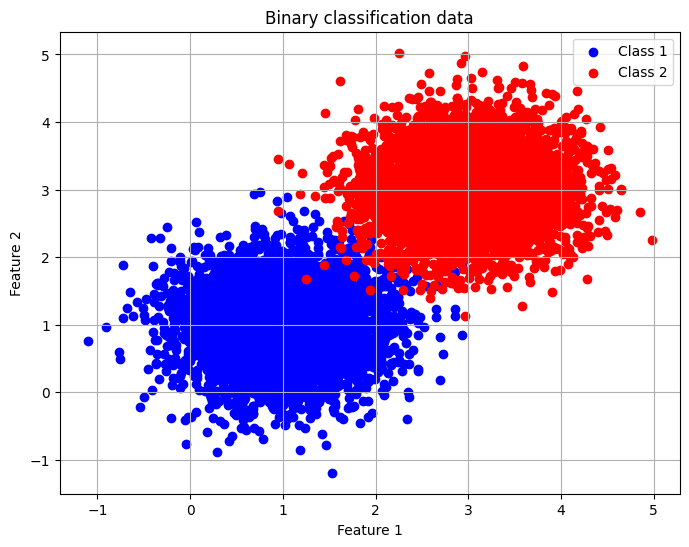

In [2]:
##################################################
#Generating binary classification data (linearly separable)
##################################################
import numpy as np
import matplotlib.pyplot as plt

mean1 = [1,1]
mean2 = [3,3]
cov = [[0.3,0],[0,0.3]]
class1_tr = np.random.multivariate_normal(mean1, cov, size=(4500))
class2_tr = np.random.multivariate_normal(mean2, cov, size=(4500))

tr_data = np.concatenate([class1_tr, class2_tr], axis=0)
tr_targets = np.concatenate([np.zeros(len(class1_tr)), np.ones(len(class2_tr))])

class1_te = np.random.multivariate_normal(mean1, cov, size=(500))
class2_te = np.random.multivariate_normal(mean2, cov, size=(500))

te_data = np.concatenate([class1_te, class2_te], axis=0)
te_targets = np.concatenate([np.zeros(len(class1_te)), np.ones(len(class2_te))])

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(class1_tr[:, 0], class1_tr[:, 1], color='blue', label='Class 1')
plt.scatter(class2_tr[:, 0], class2_tr[:, 1], color='red', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary classification data')
plt.legend()
plt.grid(True)
plt.show()


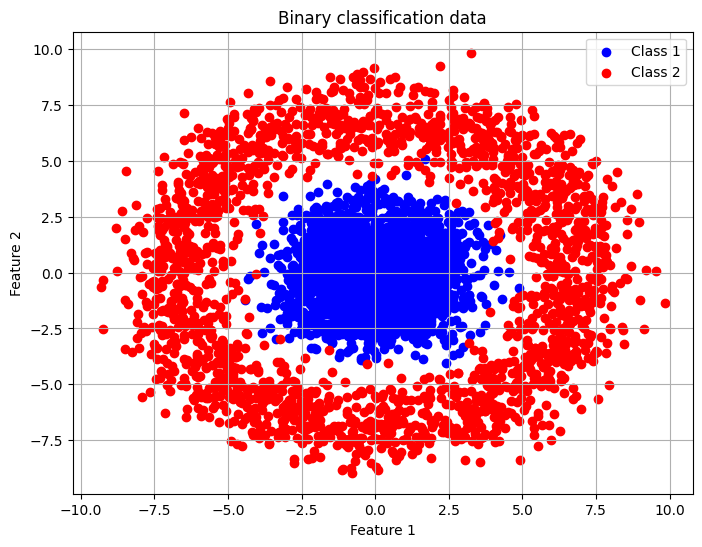

In [3]:
##################################################
#Generating binary classification data (non-linearly separable)
##################################################
import numpy as np
import matplotlib.pyplot as plt

# Function to generate data for concentric circles
def generate_concentric_data(n_samples, radius1,radius2, noise_std):
    # Generate random angles
    angles = np.random.rand(n_samples) * 2 * np.pi
    noise = noise_std*np.random.randn(n_samples)
    # Generate inner and outer circles
    inner_circle = np.array([(radius1 + noise) * np.cos(angles), (radius1 + noise) * np.sin(angles)]).T
    outer_circle = np.array([(radius2 + noise) * np.cos(angles), (radius2 + noise) * np.sin(angles)]).T
    return inner_circle, outer_circle

# Generate data for two classes
n_samples = 2000  # Number of samples for each class
radius1 = 2  # Radius of inner circle
radius2 = 7  # Radius of inner circle
noise_std = 1   # Noise to be added to radius

class1_data, class2_data = generate_concentric_data(n_samples, radius1,radius2,noise_std)

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(class1_data[:, 0], class1_data[:, 1], color='blue', label='Class 1')
plt.scatter(class2_data[:, 0], class2_data[:, 1], color='red', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary classification data')
plt.legend()
plt.grid(True)
plt.show()



Linear Classification Accuracy: 0.9961
Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7448 - loss: 0.4500
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9937 - loss: 0.0336
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9947 - loss: 0.0193
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9933 - loss: 0.0191
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9935 - loss: 0.0152
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9938 - loss: 0.0153
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9951 - loss: 0.0148
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9954 - loss: 0.0139
Epoch 9/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9923 - loss: 0.0188
Epoch 10/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9952 - loss: 0.0131
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9927 - loss: 0.0255
Deep Neural Network Accurac

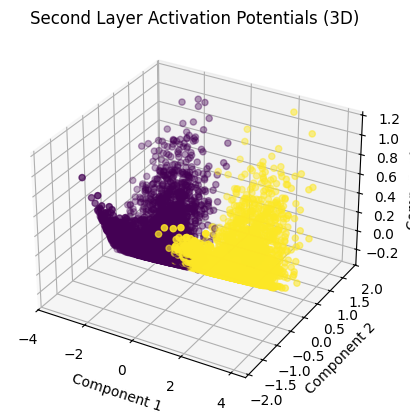

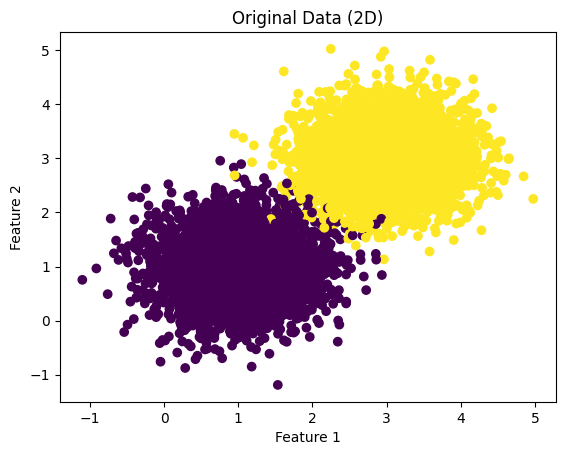

In [28]:
#part-5 first cell
##################################################
#Classify the linearly separable data using linear classification models
##################################################
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from mpl_toolkits.mplot3d import Axes3D
# Replace with your actual data loading and preprocessing
X, y = tr_data, tr_targets

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train a Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Linear Classification Accuracy: {accuracy:.4f}")


##################################################
#Classify the linearly separable data using deep neural based classification models
##################################################

# Define the deep neural network model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),  # Input layer using Input()
    tf.keras.layers.Dense(64, activation='relu'),  # Input layer with 64 units and ReLU activation
    tf.keras.layers.Dense(32, activation='relu'),  # Hidden layer with 32 units and ReLU activation
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer with 1 unit and sigmoid activation (for binary classification)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model on the test set
_, accuracy = model.evaluate(X_test, y_test)
print(f"Deep Neural Network Accuracy: {accuracy:.4f}")


##################################################
#Compare the performance of both the models on linearly separable data
##################################################
print(f"Linear Classification Accuracy: {accuracy_score(y_test, model.predict(X_test) > 0.5):.4f}")
print(f"Deep Neural Network Accuracy: {accuracy:.4f}")


# fwdPropagate function from the previous parts of your code

# Define activation functions and their gradients (if not already defined)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def grad_sigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))

def tanh(x):
    return np.tanh(x)

def grad_tanh(x):
    return 1 - np.tanh(x)**2

def leaky_relu(x, alpha=0.01):
    return np.maximum(alpha * x, x)

def grad_leaky_relu(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)

def ReLu(inp):
  outp = np.maximum(0, inp)  # Element-wise maximum between 0 and input
  return outp

#Complete the below function to impliment gradient of ReLU activation function
def gradReLu(inp):
  outp = np.where(inp > 0, 1, 0)  # 1 if input > 0, otherwise 0
  return outp

#Complete the below function to impliment softmax activation function
def softmax(inp):
  exp_inp = np.exp(inp - np.max(inp, axis=1, keepdims=True))  # Subtract max for numerical stability
  outp = exp_inp / np.sum(exp_inp, axis=1, keepdims=True)  # Normalize to get probabilities
  return outp

# Modify the fwdPropagate and computeGradients functions to use the selected activation function
def fwdPropagate(inputs, weights, activation_function):
    # Inputs: input data, parameters of network
    W1, W2, W3 = weights

    activation_func_dict = {
        'sigmoid': sigmoid,
        'tanh': tanh,
        'relu': ReLu,  # Assuming ReLu and gradReLu are defined from Part 1
        'leaky_relu': leaky_relu
    }

    activation_function = activation_func_dict[activation_function]


    # Hidden layer 1 calculations
    z1 = inputs @ W1  # Matrix multiplication for layer 1
    a1 = activation_function(z1)  # Apply activation function

    # Hidden layer 2 calculations
    z2 = a1 @ W2  # Matrix multiplication for layer 2
    a2 = activation_function(z2)  # Apply activation function

    # Output layer calculations
    z3 = a2 @ W3  # Matrix multiplication for output layer
    outps = softmax(z3)  # Apply softmax activation

    # Return the requires outputs, i.e., final output and intermediate activations
    return outps, a1, a2



from tensorflow import keras

trained_weights = [np.array(model.layers[0].get_weights()[0]), np.array(model.layers[1].get_weights()[0]), np.array(model.layers[2].get_weights()[0])]
activations = fwdPropagate(X_train, trained_weights, activation_function='relu')
# Replace 'relu' with your best activation function if different
second_layer_activations = activations[1]  # activations[2] corresponds to the second layer

# Apply dimensionality reduction (e.g., PCA) to reduce to 3 dimensions
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
reduced_activations = pca.fit_transform(second_layer_activations)

# Create a 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the reduced activation potentials
ax.scatter(reduced_activations[:, 0], reduced_activations[:, 1], reduced_activations[:, 2], c=y_train, cmap='viridis')

ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.set_title('Second Layer Activation Potentials (3D)')

plt.show()

# Create a 2D scatter plot of the original data (for comparison)
plt.figure()
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis')
# Assuming you want to plot the first two features of the original data
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original Data (2D)')
plt.show()

In [29]:
#part-5 second cell
##################################################
#Classify the non-linearly separable data using linear classification models
##################################################

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Combine the data for non-linearly separable case
X_nonlinear = np.concatenate([class1_data, class2_data], axis=0)  # Combine features
y_nonlinear = np.concatenate([np.zeros(len(class1_data)), np.ones(len(class2_data))])  # Combine targets

# Split data into train and test sets
X_train_nonlinear, X_test_nonlinear, y_train_nonlinear, y_test_nonlinear = train_test_split(
    X_nonlinear, y_nonlinear, test_size=0.2, random_state=42
)

# Create and train a Logistic Regression model
logreg_model = LogisticRegression(max_iter=1000)  # Increase max_iter if needed
logreg_model.fit(X_train_nonlinear, y_train_nonlinear)

# Make predictions on the test set
y_pred_logreg = logreg_model.predict(X_test_nonlinear)

# Calculate accuracy
accuracy_logreg = accuracy_score(y_test_nonlinear, y_pred_logreg)
print(f"Logistic Regression Accuracy: {accuracy_logreg:.4f}")


##################################################
#Classify the non-linearly separable data using deep neural based classification models
##################################################
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train_nonlinear.shape[1],)),  # Input layer
    tf.keras.layers.Dense(64, activation='relu'),  # Hidden layer with 64 units and ReLU activation
    tf.keras.layers.Dense(32, activation='relu'),  # Hidden layer with 32 units and ReLU activation
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer with 1 unit and sigmoid activation (for binary classification)
])
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the deep neural network model on the non-linearly separable data
#The name of the model was corrected from 'deep_model' to 'model'
model.fit(X_train_nonlinear, y_train_nonlinear, epochs=10, batch_size=32)  # Adjust epochs and batch_size as needed

# Make predictions on the test set
y_pred_deep = model.predict(X_test_nonlinear)
y_pred_deep = (y_pred_deep > 0.5).astype(int)  # Get predicted class labels


# Calculate accuracy
accuracy_deep = accuracy_score(y_test_nonlinear, y_pred_deep)
print(f"Deep Neural Network Accuracy: {accuracy_deep:.4f}")


##################################################
#Compare the performance of both the models on non-linearly separable data
##################################################

print(f"Logistic Regression Accuracy: {accuracy_logreg:.4f}")
print(f"Deep Neural Network Accuracy: {accuracy_deep:.4f}")


Logistic Regression Accuracy: 0.2863
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5668 - loss: 0.5724
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9028 - loss: 0.3389
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9896 - loss: 0.1059
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9938 - loss: 0.0463
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9931 - loss: 0.0302
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9933 - loss: 0.0242
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9926 - loss: 0.0249
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9914 - loss: 0.0240
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9941 - loss: 0.0213
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9936 - loss: 0.0165
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Deep Neural Network Accuracy: 0.9912
Logistic Regression Accur

<b> Report your observations </b>

1.from the plot we can tell that the neural network created a new view of the data where the different digit types were easier to separate.

2.Similar digits tended to group together in the 3D activation space, showing that the network learned to identify shared features within each digit type.

3.Compared to the original data, the 3D plot of the activations made it clearer to see the differences between the digit types, demonstrating the network's ability to pick out important features for recognizing digits.accuracy of logistic regression is affected due to non linearity of data

